In [ ]:
import scipy
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import os
from scipy.stats import *
from scipy.stats import norm, t


In [359]:
os.chdir(r'/Users/proxim/Desktop/CDAC-DBDA-coursework/08.advanced-analytics-stats')

#### boxplot

In [217]:
# A boxplot visualizes the distribution of numeric data and highlights spread & outliers.
# Key features:
# - Median: the central line inside the box (middle value).
# - Box (IQR): spans from Q1 to Q3 (middle 50% of the data).
# - Whiskers: extend to the minimum and maximum values within 1.5 * IQR.
# - Outliers: points outside the whiskers, shown as individual dots.
# Boxplots are useful for comparing multiple groups and spotting skewness or outliers quickly.

![image](https://www.onlinemathlearning.com/image-files/box-plot.png)



$$
\text{IQR} = Q_3 - Q_1
$$

In [218]:
# NOTE:
# Outliers are values which are greater than the upper bound OR less than the lower bound.

# upper bound = Q3 + 1.5 * IQR
# lower bound = Q1 - 1.5 * IQR

# Whiskers:
# - Upper whisker = the largest data point that is still ≤ upper bound.
# - Lower whisker = the smallest data point that is still ≥ lower bound.

# Any value outside these bounds (above upper bound or below lower bound) is considered an OUTLIER.

In [219]:
df = pd.read_excel('data/Values.xlsx')

In [220]:
df.head()

,Values
0,32
1,38
2,128
3,49
4,44


In [221]:
q1 = np.percentile(df.Values, 25)
q2 = np.percentile(df.Values, 50)
q3 = np.percentile(df.Values, 75)

uf = q3 + 1.5 * (q3-q1)
lf = q1 - 1.5 * (q3-q1)

In [222]:
(df.Values>uf).sum()

np.int64(7)

In [223]:
(df.Values<lf).sum()

np.int64(6)

In [224]:
# Find all values between Q3 and the Upper Bound (UF = Q3 + 1.5*IQR).
# These are the highest values that are NOT outliers.
# The maximum of these values becomes the UPPER WHISKER.
ind = np.where((df.Values > q3) & (df.Values <= uf))
max(df.Values.iloc[ind])

75

In [225]:
# Find all values between the Lower Bound (LF = Q1 - 1.5*IQR) and Q1.
# These are the smallest values that are NOT outliers.
# The minimum of these values becomes the LOWER WHISKER.
ind = np.where((df.Values < q1) & (df.Values >= lf))
min(df.Values.iloc[ind])

24

In [226]:
# Upper outliers: values greater than the Upper Bound (UF).
ind = np.where(df.Values > uf)
df.Values.iloc[ind]

2      128
119    116
251     77
288     89
394     81
445    120
467    127
Name: Values, dtype: int64

In [227]:
# Lower outliers: values less than the Lower Bound (LF).
ind = np.where(df.Values < lf)
df.Values.iloc[ind]

32     18
61    -21
284   -25
302   -27
321   -17
427   -24
Name: Values, dtype: int64

In [228]:
df.head()

,Values
0,32
1,38
2,128
3,49
4,44


In [229]:
df = pd.read_excel('data/Travel.xlsx')

In [230]:
df.head()

,Gender,Location,TransportMode
0,Female,Suburbs,Cab
1,Male,City,Cab
2,Female,Towns,Bus
3,Female,Suburbs,LocalTrain
4,Male,Suburbs,Bus


In [231]:
np.unique(df.Location)

array(['City', 'Suburbs', 'Towns'], dtype=object)

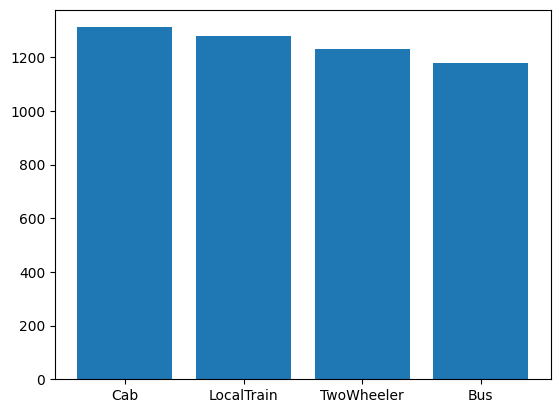

In [232]:
s1 = df.TransportMode.value_counts()
plt.bar(s1.index, s1.values)
plt.show()

In [233]:
df.head()

,Gender,Location,TransportMode
0,Female,Suburbs,Cab
1,Male,City,Cab
2,Female,Towns,Bus
3,Female,Suburbs,LocalTrain
4,Male,Suburbs,Bus


In [234]:
df.head()

,Gender,Location,TransportMode
0,Female,Suburbs,Cab
1,Male,City,Cab
2,Female,Towns,Bus
3,Female,Suburbs,LocalTrain
4,Male,Suburbs,Bus


In [235]:
t1 = df.TransportMode.value_counts()

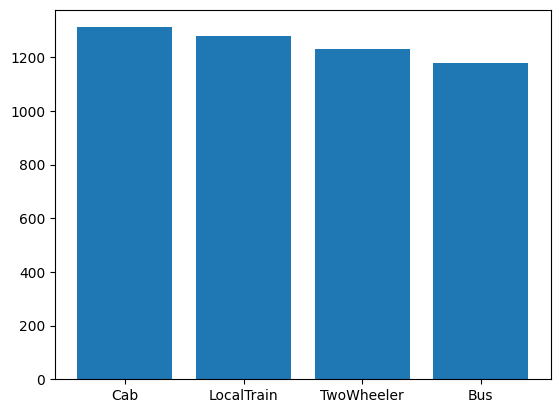

In [236]:
plt.bar(t1.index, t1.values)
plt.show()

In [237]:
# df = df.reset_index()

In [238]:
df.head()

,Gender,Location,TransportMode
0,Female,Suburbs,Cab
1,Male,City,Cab
2,Female,Towns,Bus
3,Female,Suburbs,LocalTrain
4,Male,Suburbs,Bus


In [239]:
df2 = df.TransportMode.value_counts().reset_index()

In [240]:
df2.head()

,TransportMode,count
0,Cab,1312
1,LocalTrain,1281
2,TwoWheeler,1230
3,Bus,1177


In [241]:
df2 = df2.sort_values('count', ascending=False)


In [242]:
df2['prop'] = df2['count']/sum(df2['count'])

In [243]:
df2.head()

,TransportMode,count,prop
0,Cab,1312,0.2624
1,LocalTrain,1281,0.2562
2,TwoWheeler,1230,0.2460
3,Bus,1177,0.2354


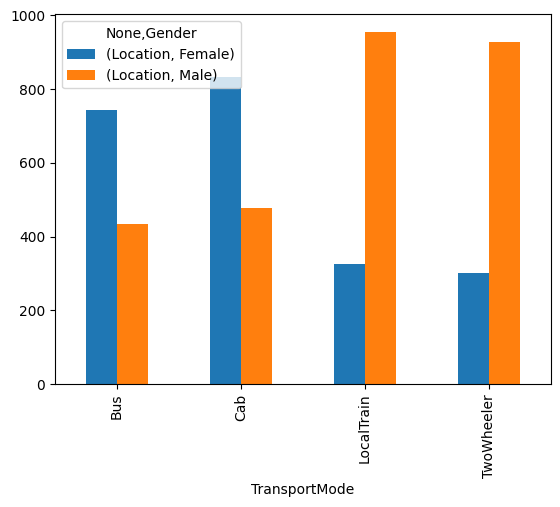

In [252]:
df2 = df.pivot_table(columns='Gender',index='TransportMode', aggfunc=np.size).plot(kind='bar')
plt.show()

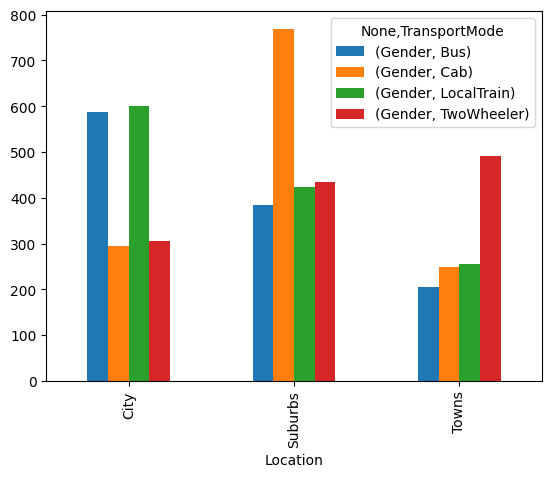

In [250]:
df2 = df.pivot_table(columns='TransportMode',index='Location', aggfunc=np.size).plot(kind='bar')
plt.show()

In [291]:
df = pd.read_excel('data/Responses.xlsx')

In [292]:
df.head()

,Gender,Education,Occupation,Response1,Response2
0,Male,HighSchool,Banking,115.4,23.0
1,NaN,NaN,Software,38.0,26.0
2,NaN,College,Manufacturing,56.7,36.0
3,Male,PostGrad,Manufacturing,52.6,38.0
4,Male,PostGrad,Banking,62.7,55.0


In [293]:
n = df.isnull().sum().reset_index()

In [294]:
n.head()

,index,0
0,Gender,441
1,Education,245
2,Occupation,368
3,Response1,175
4,Response2,200


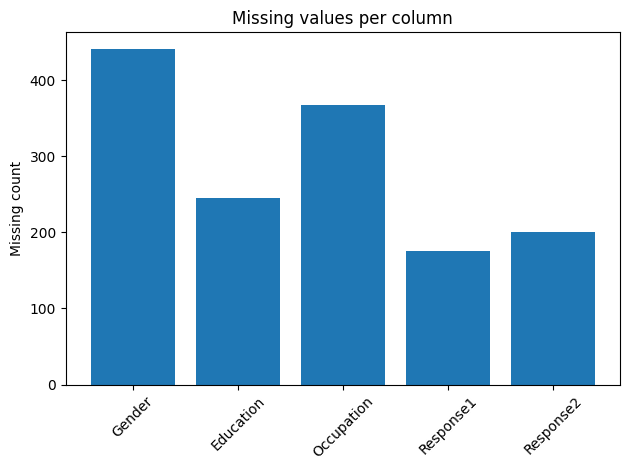

In [295]:
plt.bar(n['index'], n[0])
plt.xticks(rotation=45)
plt.ylabel('Missing count')
plt.title('Missing values per column')
plt.tight_layout()
plt.show()

In [296]:
df.head()

,Gender,Education,Occupation,Response1,Response2
0,Male,HighSchool,Banking,115.4,23.0
1,NaN,NaN,Software,38.0,26.0
2,NaN,College,Manufacturing,56.7,36.0
3,Male,PostGrad,Manufacturing,52.6,38.0
4,Male,PostGrad,Banking,62.7,55.0


In [297]:
df.Gender.value_counts().reset_index()

,Gender,count
0,Male,2324
1,Female,2235


In [298]:
# Calculate the value counts (proportions) for non-NaN values
probs = df['Gender'].value_counts(normalize=True)

In [304]:
probs

Gender
Male      0.509761
Female    0.490239
Name: proportion, dtype: float64

In [ ]:
# Find indices where Gender is NaN
nan_idx = df['Gender'][df['Gender'].isna()].index

In [306]:
nan_idx

Index([   1,    2,   10,   21,   28,   36,   38,   46,   53,   89,
       ...
       4833, 4843, 4850, 4854, 4867, 4873, 4876, 4904, 4964, 4969],
      dtype='int64', length=441)

In [300]:
# Randomly assign values to NaNs based on the observed proportions
df.loc[nan_idx, 'Gender'] = np.random.choice(probs.index, size=len(nan_idx), p=probs.values)

In [301]:
# df.Gender = df.Gender.fillna('Male')

In [302]:
df.head()

,Gender,Education,Occupation,Response1,Response2
0,Male,HighSchool,Banking,115.4,23.0
1,Male,NaN,Software,38.0,26.0
2,Female,College,Manufacturing,56.7,36.0
3,Male,PostGrad,Manufacturing,52.6,38.0
4,Male,PostGrad,Banking,62.7,55.0


In [307]:
df.Gender.value_counts().value_counts(normalize=True)

count
2570    0.5
2430    0.5
Name: proportion, dtype: float64

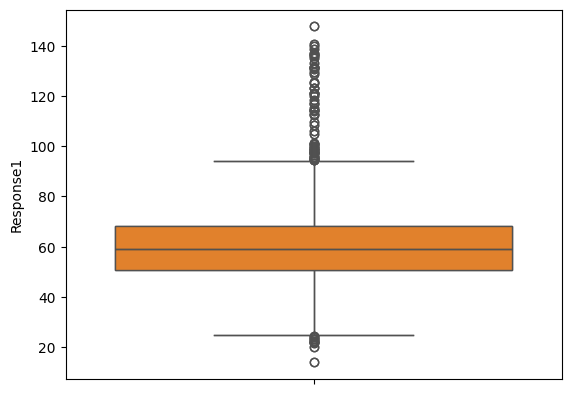

In [311]:
sns.boxplot(df.Response1)
plt.show()

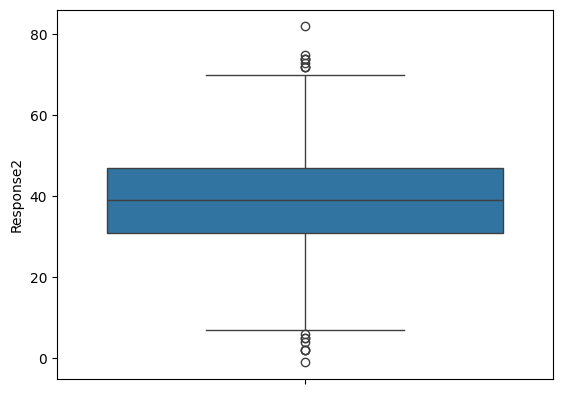

In [312]:
sns.boxplot(df.Response2)
plt.show()

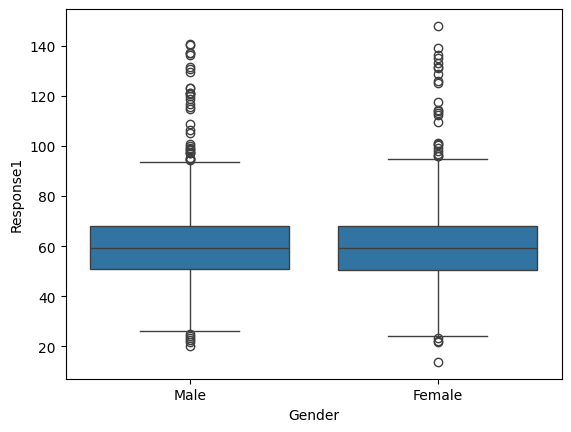

In [313]:
dfm = df.iloc[np.where(df.Gender=="Male")]
dff = df.iloc[np.where(df.Gender=="Female")]

sns.boxplot(x=df.Gender, y = df.Response1)
plt.show()

In [314]:
dfm = df.iloc[np.where(df.Gender=="Male")]
dff = df.iloc[np.where(df.Gender=="Female")]


,Gender,Education,Occupation,Response1,Response2
0,Male,HighSchool,Banking,115.4,23.0
1,Male,NaN,Software,38.0,26.0
2,Female,College,Manufacturing,56.7,36.0
3,Male,PostGrad,Manufacturing,52.6,38.0
4,Male,PostGrad,Banking,62.7,55.0


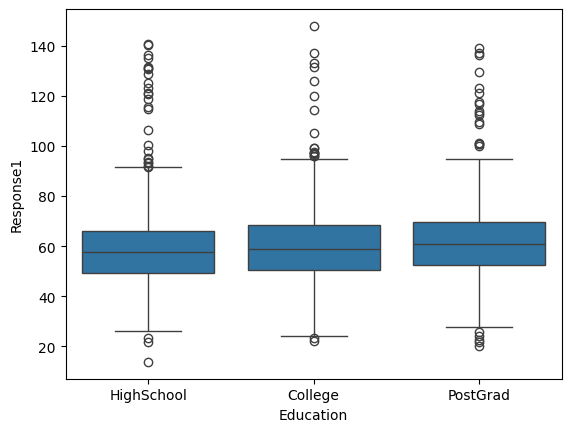

In [317]:
sns.boxplot(x=df.Education, y = df.Response1)
plt.show()

In [ ]:
# Discrete - binomial and poisson
# Continouos. exponential, 



# it is always used for discrete data
# binomial distribution is used when there are only 2 possibilities

# the probability of single occurence is known
# binomial distribution to calculate the probablity of a particular range of events


In [ ]:
import scipy
from scipy import stats
from scipy.stats import binom, poisson

In [322]:
binom.pmf(10,15,0.6)  # binom.pmf = Binomial Probability Mass Function

np.float64(0.1859378447646719)

In [323]:
binom.pmf(10,15,0.6)

np.float64(0.1859378447646719)

In [330]:
binom.cdf(10,15,0.6)     # cumilitive distributed function, from 1-10, out of 15

np.float64(0.782722294349824)

In [327]:
1 - binom.cdf(9,15,0.6)

np.float64(0.403215550414848)

In [328]:
binom.sf(9,15,0.6)

np.float64(0.40321555041484797)

In [329]:
binom.pmf(10,15,0.6)

np.float64(0.1859378447646719)

In [331]:
binom.cdf(8,15,0.6) - binom.cdf(2,15,0.6)

np.float64(0.38990793985228805)

In [ ]:
# poisson distribution

# either the probability of the event is very small or can't be calculated


# number of times the event occurs is more suitable to be calculated
# we have historical records or the frequency of the event occurs


In [332]:
poisson.pmf(45, 50) #Answer -1

np.float64(0.045826241434197924)

In [333]:
poisson.cdf(45, 50)

np.float64(0.2668664740596442)

In [334]:
poisson.cdf(45, 60)

np.float64(0.026582064716936457)

In [335]:
1 - poisson.cdf(44,50)

np.float64(0.7789597673745553)

In [ ]:
from scipy.stats import expon # exponential distribution

In [339]:
expp = expon.cdf(100, scale = 43.8)

In [338]:
1 - expon.cdf(100, scale = 43.8)

np.float64(0.10196710447804302)

In [340]:
expon.ppf(expp, scale = 43.8)

# ppf = Percent Point Function
# also called the inverse CDF.

np.float64(100.0)

In [341]:
expon.ppf(0.6, scale = 43.8)

np.float64(40.13353405608799)

In [342]:
expon.ppf(0.99, scale = 43.8)

np.float64(201.70645414627836)

In [ ]:
# any normal distribution is characterized or defined by 
# 1. mean 
# 2. standard deviation


# avg time to kolhpaur from mumbai is 5 hours with std dev as 1.3 horus



In [344]:
binom.cdf(4.5,5,1.3)

np.float64(nan)

In [345]:
# what is the probability that i will take less than 4.5 hours

norm.cdf(4.5,5, 1.3)

np.float64(0.3502611970519244)

In [347]:
# what is the probability that i will take more than 4.5 hours
1 - norm.cdf(4.5,5, 1.3) 

np.float64(0.6497388029480756)

In [348]:
# what is the probability that i will take time between 4.2 and 5.3 hours

norm.cdf(5.3,5,1.3) - norm.cdf(4.2,5,1.3)

np.float64(0.32210258230894806)

In [355]:
expon.ppf(0.99, scale = 4)

np.float64(18.420680743952364)

Z score formula
$$z = \frac{x - \mu}{\sigma}$$

In [352]:
# what is the time below which 65% of trips gets completed
norm.ppf(0.65,5)


-0.3846153846153846

In [356]:
z =(4.5-5)/1.3
z

-0.3846153846153846

In [350]:
#  for standard normal curve   ->  mean is 0 , std is 1


In [358]:
norm.cdf(z,)

np.float64(0.3502611970519244)